In [1]:
import numpy as np
import scipy
import astropy
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from scipy import stats, integrate
from astropy.visualization import hist
from tqdm.notebook import tqdm
import math

the spin is uniformly distributed between 0 and 1.
the mass is normally distributed.
(masses and spins are uncorrelated)

In [3]:
N= 10000
np.random.seed(42) 
spin = stats.uniform.rvs(loc=0, scale=1, size=N) #uniform distribution for spin 
mu = 1 #all the masses are distributed in unit of mu 
mass = scipy.stats.norm.rvs(loc=mu,scale=0.02,size=N)

### production of hist without constrain on the bin 

Text(0.5, 0, 'spin')

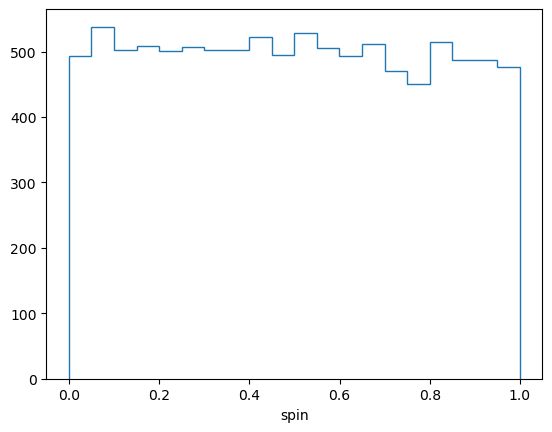

In [5]:
plt.hist(spin, bins=20, histtype="step")
plt.xlabel("spin")

Text(0.5, 0, 'mass')

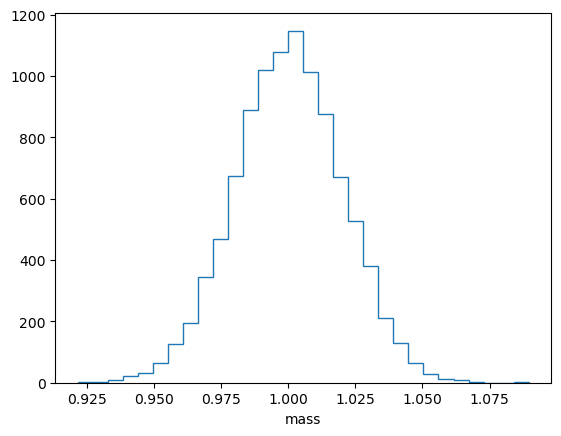

In [6]:
plt.hist(mass, bins=30, histtype="step")
plt.xlabel("mass")

In [7]:
def f_spin(S):
    return np.sqrt((1+np.sqrt(1-S**2))/2)

In [8]:
def M_irr(M,S): #definition of irreducible mass using function above 
    return M*f_spin(S)

### possible way to visualize an histogram: plotting pdf of the irreducible mass

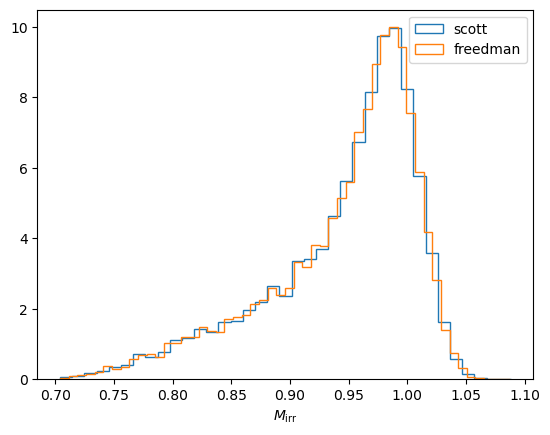

In [10]:
astropy.visualization.hist(M_irr(mass,spin), bins="scott", histtype="step",density=True, label="scott") #when is similar to a gaussian
astropy.visualization.hist(M_irr(mass, spin), bins="freedman", histtype="step",density=True, label="freedman")
plt.xlabel('$M_{\\rm irr}$')
plt.legend()

### plot the distribution of irreducible mass using a KDE 

In [67]:
xgrid = np.linspace(M_irr(mass, spin).min(),M_irr(mass, spin).max(),1000) 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

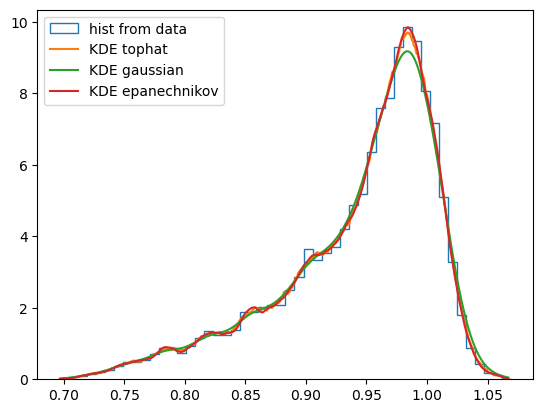

In [69]:
#data
astropy.visualization.hist(M_irr(mass, spin), bins="freedman", histtype="step",density=True, label="hist from data")
#KDE  bandwidth 0.01
PDFtophat = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="tophat") 
PDFgaussian = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="gaussian")
PDFep = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="epanechnikov")
#plot
plt.plot(xgrid,PDFtophat, label="KDE tophat") 
plt.plot(xgrid,PDFgaussian, label="KDE gaussian")
plt.plot(xgrid,PDFep, label="KDE epanechnikov") 
plt.legend()

### KS test

In [72]:
print(stats.ks_2samp(M_irr(mass,spin)/mu, f_spin(spin)))

KstestResult(statistic=0.1577, pvalue=7.052754369231086e-109, statistic_location=0.9999999997136335, statistic_sign=-1)


In [74]:
print(stats.ks_2samp(mass, M_irr(mass,spin)))

KstestResult(statistic=0.5, pvalue=0.0, statistic_location=0.9736493568071716, statistic_sign=-1)


In [76]:
#sigma = np.linespace(10**-4, 10**4, 40)
sigma = np.logspace(-4,4,40)
result_ks_f = []
result_ks_M = []

for s in sigma:

    mass_s = scipy.stats.norm.rvs(loc=mu,scale=s,size=10000) #generating a gaussian distribution for every sigma
    stat_f, p_f = stats.ks_2samp(f_spin(spin), M_irr(mass_s,spin)/1) #crf with f
    stat_M, p_M = stats.ks_2samp(mass_s, M_irr(mass_s,spin)) #cfr with M
    result_ks_f.append(stat_f)
    result_ks_M.append(stat_M)


In [77]:
#print(result_ks_f)
#print(result_ks_M)

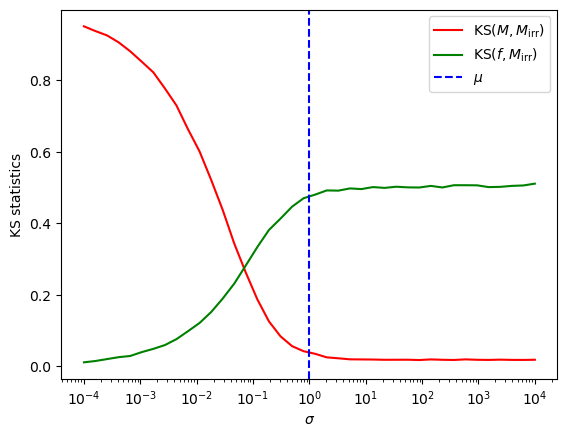

In [80]:
plt.plot(sigma,result_ks_M,label="KS$(M, M_{\\rm irr})$", color="red")
plt.plot(sigma,result_ks_f,label="KS$(f,M_{\\rm irr})$", color="green")
plt.axvline(1, linestyle='--', label=r"$\mu$", color="blue")
plt.xscale('log')
plt.xlabel(r"$\sigma$")
plt.ylabel('KS statistics')
plt.legend()

$M_{irr}$ distributed like $f$ for $\sigma \ll \mu$, so $KS(f, M_{irr})$ goes to zero. \
$M_{irr}$ distributed like $M$ for $\sigma \gg \mu$, so $KS(M, M_{irr})$ goes to zero. 

In [83]:
f = f_spin(spin)
f_integration = np.linspace(1/2**0.5,1,500, endpoint=True)

def pdf_f(f_int):
    return 2*(2*f_int-1)/np.sqrt(1-f_int**2)

pdf_f = pdf_f(f_integration)
#print(pdf_f)

C:\Users\User\AppData\Local\Temp\ipykernel_16808\598593856.py:5: RuntimeWarning: divide by zero encountered in divide
  return 2*(2*f_int-1)/np.sqrt(1-f_int**2)


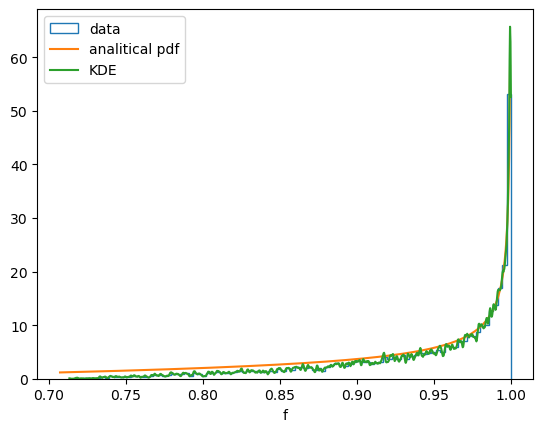

In [85]:
#from data
plt.hist(f,density=True, bins=100, histtype='step', label="data")

#analitical computation of the pdf of f 
plt.plot(f_integration[:-1],pdf_f[:-1], label="analitical pdf")
plt.xlabel("f")

#KDE
xgrid = np.linspace(f.min(),f.max(),1000) 
PDFf = kde_sklearn(f,bandwidth=0.001,kernel="epanechnikov")
plt.plot(xgrid,PDFf, label="KDE") 

plt.legend()

In [87]:
#useful quantities
mu = 1 #all the masses are distributed in unit of mu 
mass = scipy.stats.norm.rvs(loc=mu,scale=0.02,size=N)
spin = stats.uniform.rvs(loc=0, scale=1, size=N)
estimated_mirr = np.linspace(min(1-5*0.02, 1/np.sqrt(2)),1+5*0.02,N) 


#remember that mass and spin are indipendent

def pdf_Mirr(f_val,m_val):
    return ((2/np.pi)**0.5 / 0.02 ) * np.exp(-(m_val /f_val -1)**2 /(2*0.02**2)) * (2*f_val**2-1)/(1 -f_val**2)**0.5 / f_val


Mirr_from_pdf = []

for m in estimated_mirr:
    integrand = lambda f: pdf_Mirr(f,m)
    I, err = scipy.integrate.quad(integrand, a=(1 / (2**0.5)), b=1)
    Mirr_from_pdf.append(I)


10000


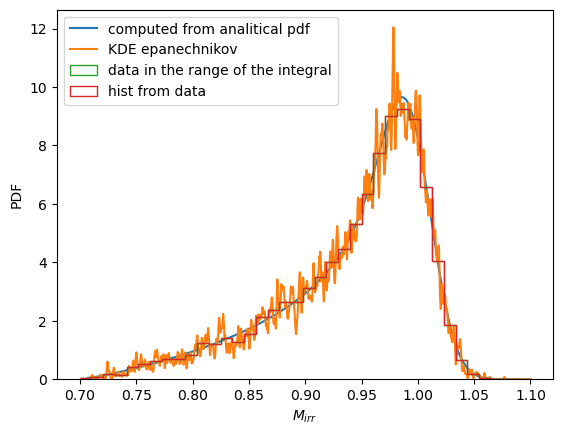

In [96]:
plt.plot(estimated_mirr, Mirr_from_pdf, label="computed from analitical pdf")

mirr = M_irr(mass, spin)
print(len(mirr))
#computing Mirr in the extreme of integration 
Mirr = []
f_grid = np.linspace(1/np.sqrt(2), 1, 10000, endpoint=True) #this is the interval of integration
for m,s in zip(mass,spin):
    Mirr.append(M_irr(m,s))


#KDE  bandwidth 0.001
#x_grid = np.linspace(M_irr(mass, spin).min(),M_irr(mass, spin).max(),10000) 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(estimated_mirr[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)
    
PDFm = kde_sklearn(M_irr(mass, spin),bandwidth=0.001,kernel="epanechnikov")
#plot
plt.plot(estimated_mirr,PDFm, label="KDE epanechnikov") 


astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True, label="data in the range of the integral")
astropy.visualization.hist(mirr, bins="scott", histtype="step",density=True, label="hist from data")
plt.xlabel(r"$M_{irr}$")
plt.ylabel(r"PDF")
plt.legend()